In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import openpyxl

file = r"C:\Users\braab\OneDrive\Desktop\Customer Churn\raw_data.xlsx"

excel_file = pd.ExcelFile(file)

print(excel_file.sheet_names)

['Demographic', 'Location', 'Account']


In [4]:
df=pd.read_excel(file, sheet_name="Demographic")

In [5]:
df

,CustomerId,Name,Gender,Age,Salary,LocationId,Churned
0,15634602,Hargrave,Female,42,101348.88,2,1
1,15647311,Hill,Female,41,112542.58,6,0
2,15619304,Onio,Female,42,113931.57,4,1
3,15701354,Boni,Female,39,93826.63,1,0
4,15737888,Mitchell,Female,43,79084.10,4,0
...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,Male,39,96270.64,4,0
9996,15569892,Johnstone,Male,35,101699.77,4,0
9997,15584532,Liu,Female,36,42085.58,1,1
9998,15682355,Sabbatini,Male,42,92888.52,6,1


In [6]:
#sanity check for the columns for categrical columns
def sanity_check(data,feature,valid_values ):
    validation=data[data[feature].isin(valid_values)]
    values_counts_column=data[feature].value_counts()
    return validation ,  values_counts_column
    
valid_valuess=["Male","Female"]
sanity_check(df,"Gender",valid_valuess)


(      CustomerId       Name  Gender  Age     Salary  LocationId  Churned
 0       15634602   Hargrave  Female   42  101348.88           2        1
 1       15647311       Hill  Female   41  112542.58           6        0
 2       15619304       Onio  Female   42  113931.57           4        1
 3       15701354       Boni  Female   39   93826.63           1        0
 4       15737888   Mitchell  Female   43   79084.10           4        0
 ...          ...        ...     ...  ...        ...         ...      ...
 9995    15606229   Obijiaku    Male   39   96270.64           4        0
 9996    15569892  Johnstone    Male   35  101699.77           4        0
 9997    15584532        Liu  Female   36   42085.58           1        1
 9998    15682355  Sabbatini    Male   42   92888.52           6        1
 9999    15628319     Walker  Female   28   38190.78           1        0
 
 [10000 rows x 7 columns],
 Gender
 Male      5457
 Female    4543
 Name: count, dtype: int64)

In [7]:
def checking_dataInfo(data):
    data.info()
    shape = data.shape
    dtypes_of_column = data.dtypes
    nulls = data.isnull().sum()
    print("Shape:", shape)
    print("\nData types:")
    print(dtypes_of_column)
    print("\nNull values:")
    print(nulls)

checking_dataInfo(df)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerId  10000 non-null  int64  
 1   Name        10000 non-null  str    
 2   Gender      10000 non-null  str    
 3   Age         10000 non-null  int64  
 4   Salary      10000 non-null  float64
 5   LocationId  10000 non-null  int64  
 6   Churned     10000 non-null  int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 657.8 KB
Shape: (10000, 7)

Data types:
CustomerId      int64
Name              str
Gender            str
Age             int64
Salary        float64
LocationId      int64
Churned         int64
dtype: object

Null values:
CustomerId    0
Name          0
Gender        0
Age           0
Salary        0
LocationId    0
Churned       0
dtype: int64


In [8]:
def related_to_sanityCheck(data,feature):
    unique=data[feature].nunique()
    counts_values=data[feature].value_counts()
    upnoraml_pattern=df[feature].astype(str).str.extract(r"([A-Za-z]+)")[0].value_counts()
    data["name_length"] = data[feature].str.len()
    data["name_length"].value_counts().sort_index()
    print(unique)
    print(upnoraml_pattern)
    print(data["name_length"])


related_to_sanityCheck(df,"Name")
    


2932
0
Ch           82
T            49
Ts           46
Lo           33
Smith        32
             ..
Salinas       1
Cleveland     1
Kashiwagi     1
Aldridge      1
Burbidge      1
Name: count, Length: 2889, dtype: int64
0       8
1       4
2       4
3       4
4       8
       ..
9995    8
9996    9
9997    3
9998    9
9999    6
Name: name_length, Length: 10000, dtype: int64


mean of the Age : 38.92
median of the Age : 37.00
mode of the Age : 37.00


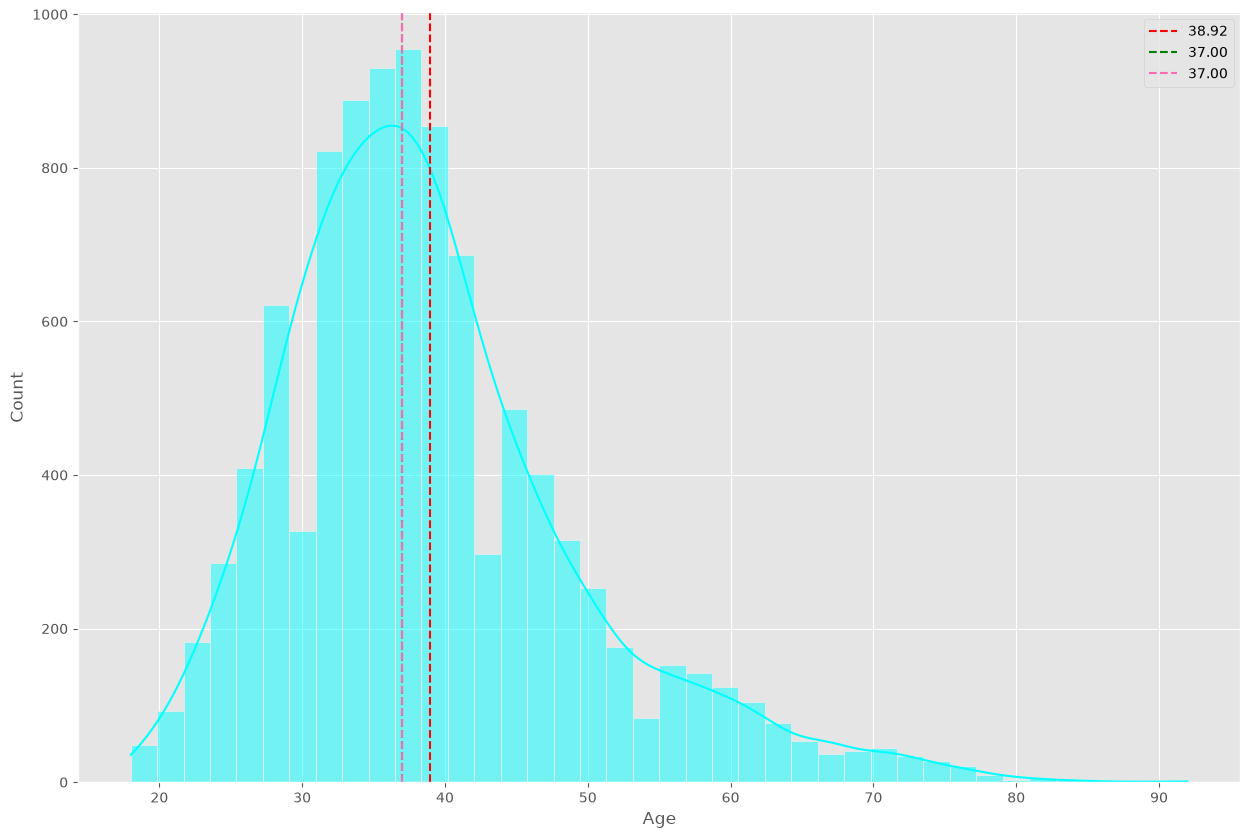



Difference between mean and median :1.92
Distribution is positively skewed (+ve skewed)
mean of the Salary : 100090.24
median of the Salary : 100193.91
mode of the Salary : 24924.92


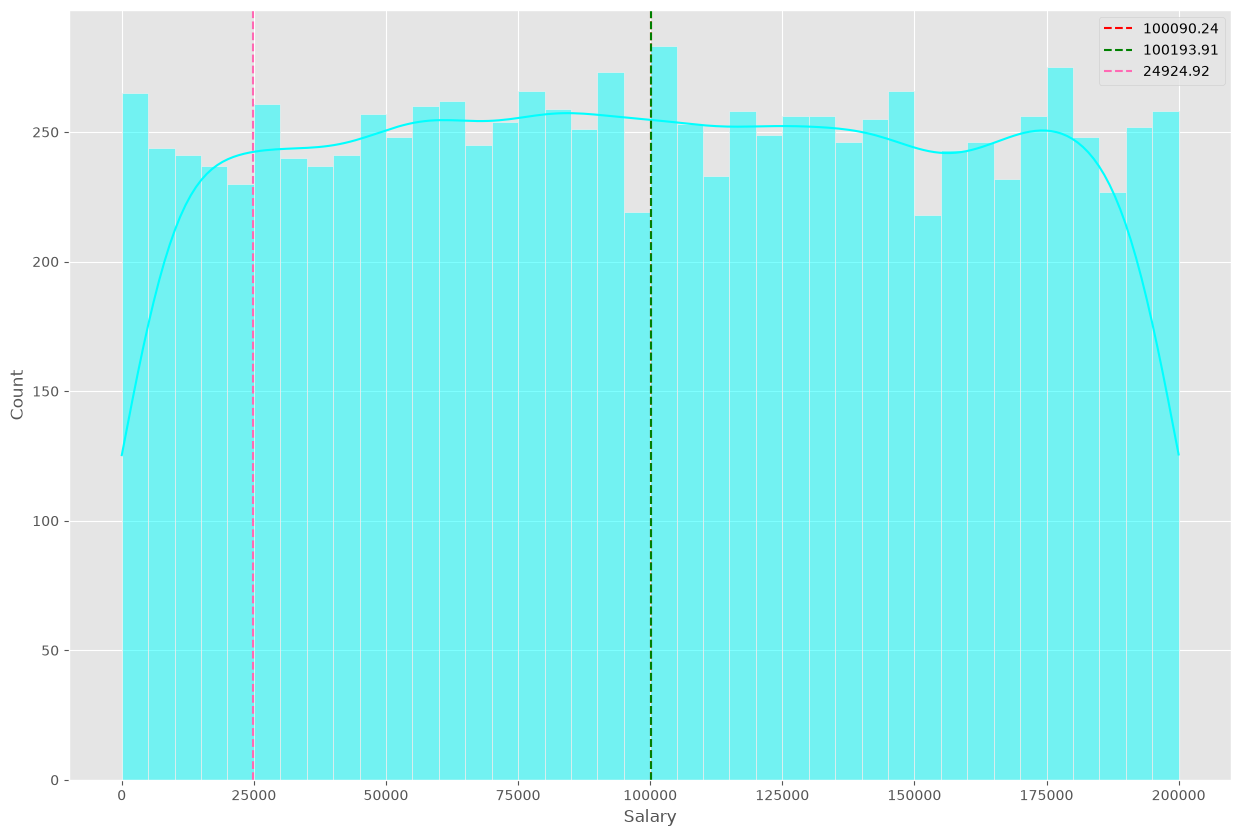



Difference between mean and median :103.68
Distribution is negatively skewed (-ve skewed)


In [16]:
plt.style.use("ggplot")
from scipy import stats
def distribution(data,feature):
    mean=data[feature].mean()
    median=data[feature].median()
    mode=data[feature].mode()[0]
    difference=abs(mean-median)
    print(f"mean of the {feature} : {mean:.2f}")
    print(f"median of the {feature} : {median:.2f}")
    print(f"mode of the {feature} : {mode:.2f}")
    plt.figure(figsize=(15,10))
    sns.histplot(data[feature],color="cyan",kde=True,bins=40)
    plt.axvline(mean,color="red",label=f"{mean:.2f}",linestyle="--")
    plt.axvline(median,color="green",label=f"{median:.2f}",linestyle="--")
    plt.axvline(mode,color="hotpink",label=f"{mode:.2f}",linestyle="--")
    plt.legend()

    plt.show()
    print("\n")
    print(f"Difference between mean and median :{difference:.2f}")
    
    if mean > median:
        print("Distribution is positively skewed (+ve skewed)")
    elif mean < median:
        print("Distribution is negatively skewed (-ve skewed)")
    else:
        print("Mean ≈ Median → distribution may be approximately symmetric")   
columns_dist=["Age","Salary"]   
for col in columns_dist:
    distribution(df,col)

feat Age
 number of outlier 359
outlier percentage 3.59%
upper bound 62.00
lower bound 14.00


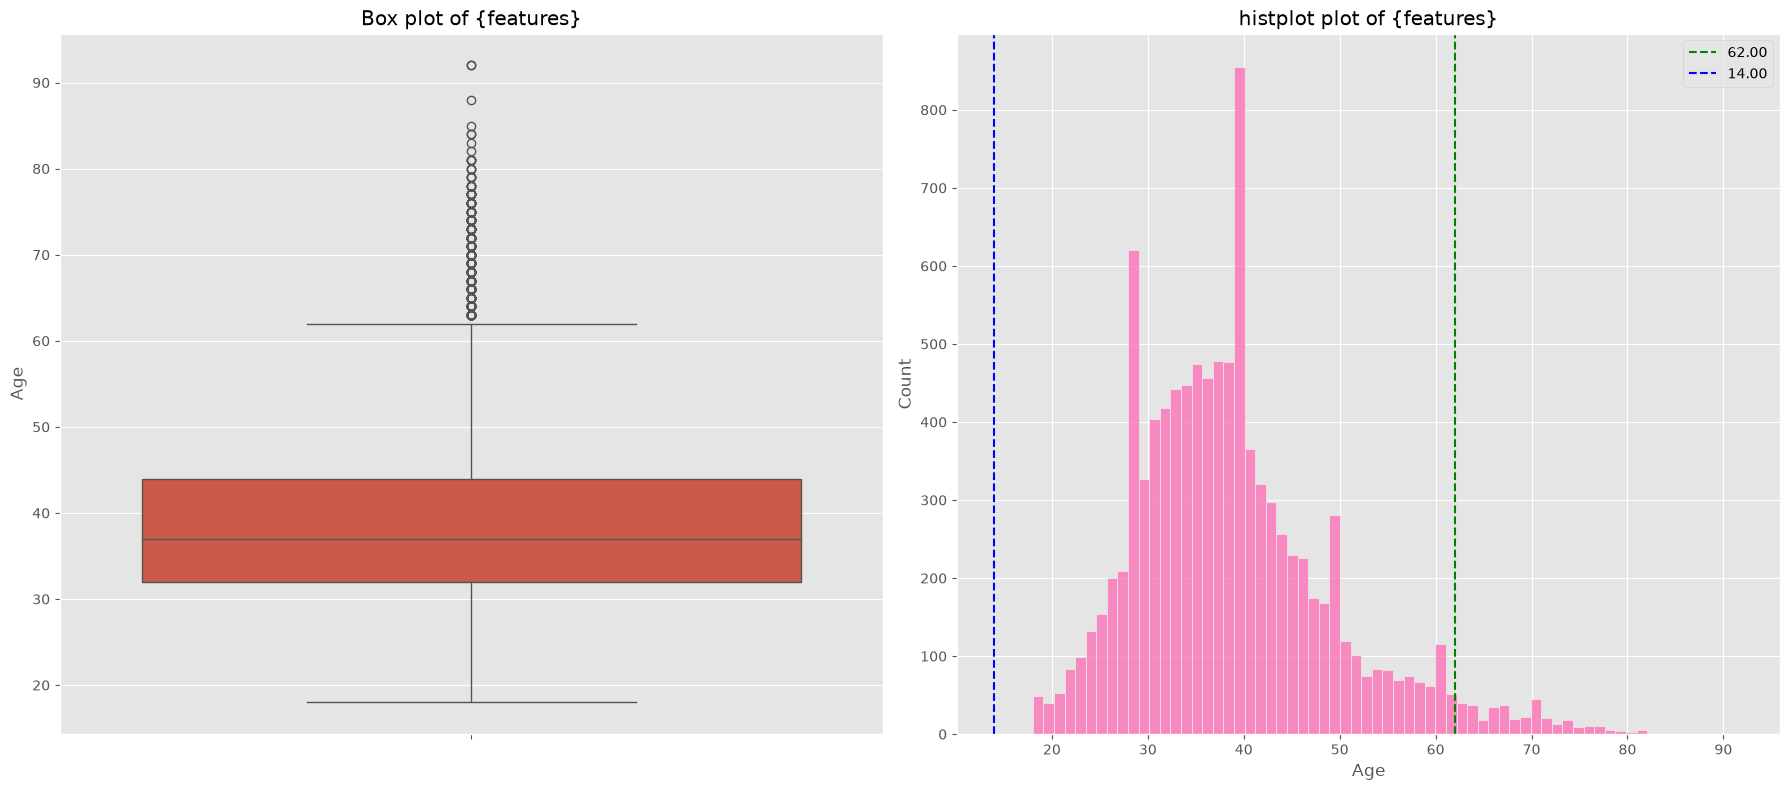

feat Salary
 number of outlier 0
outlier percentage 0.00%
upper bound 296967.45
lower bound -96577.10


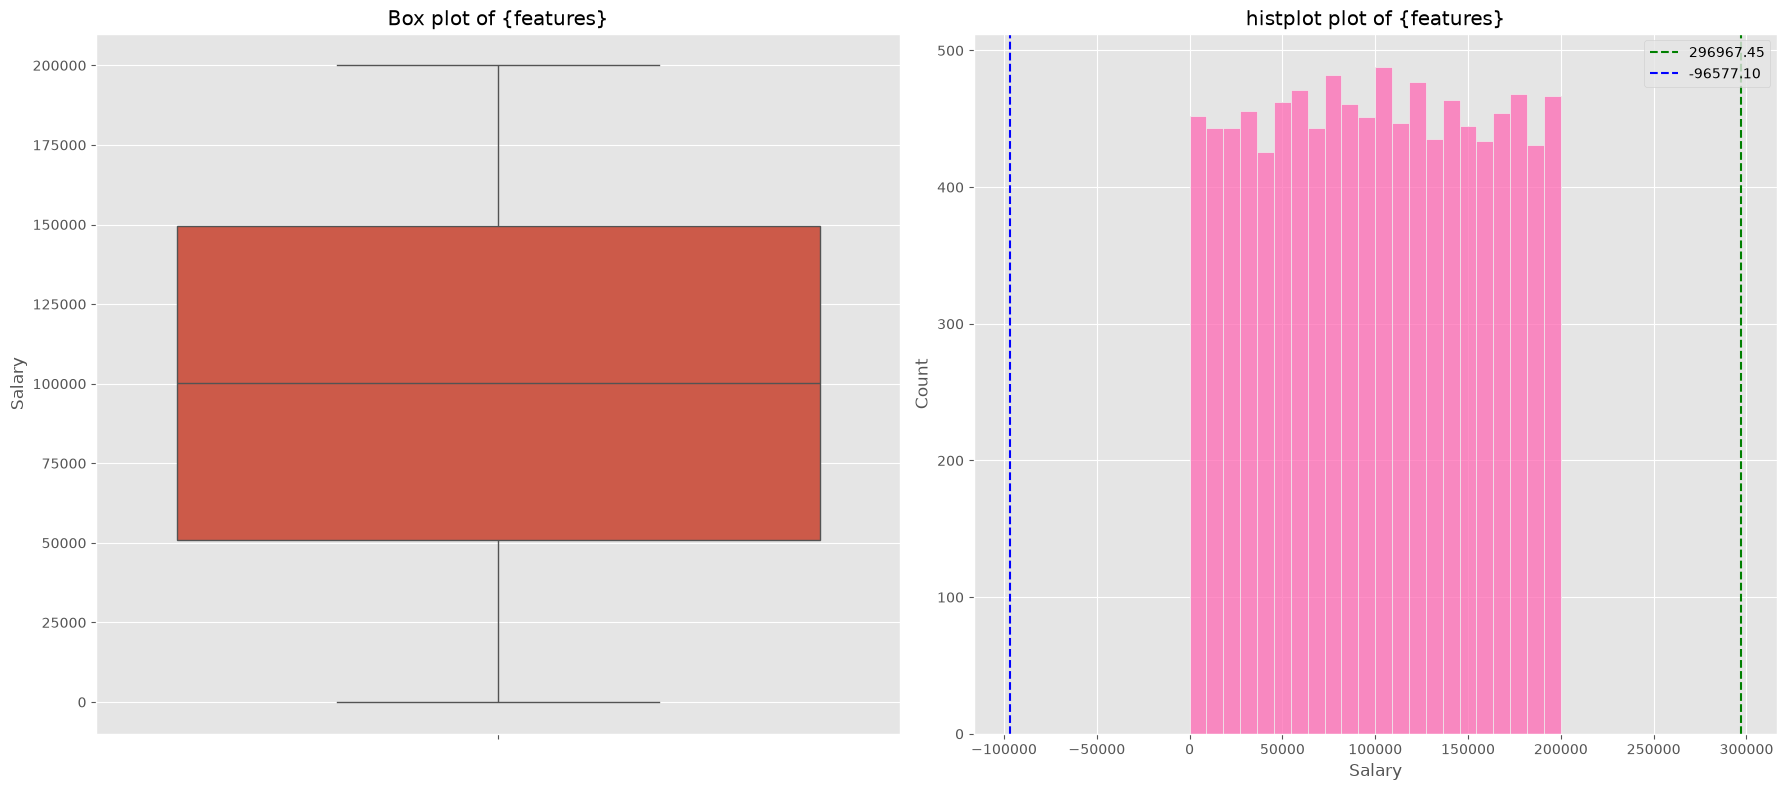

In [20]:
def detecting_outliers(data, features):
    Q1 = data[features].quantile(0.25)
    Q3 = data[features].quantile(0.75)
  
    IQR = Q3 - Q1
  
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    outlier_detector = (
            (data[features] > upper_bound) |
            (data[features] < lower_bound)
        )
    

    outlier_count = outlier_detector.sum()

    print(f"feat {features}")
    print(f" number of outlier {outlier_count}")
    print(f"outlier percentage {(outlier_count/len(data))*100:.2f}%")
    print(f"upper bound {upper_bound:.2f}")
    print(f"lower bound {lower_bound:.2f}")
    plt.figure(figsize=(18,8))

    plt.subplot(1,2,1)
    sns.boxplot(y=data[features])
    plt.title("Box plot of {features}")

    plt.subplot(1,2,2)
    sns.histplot(data[features],color="hotpink")
    plt.title("histplot plot of {features}")
    plt.axvline(upper_bound,linestyle="dashed",label=f"{upper_bound:.2f}",color="green")
    plt.axvline(lower_bound,linestyle="dashed",label=f"{lower_bound:.2f}",color="blue")

    plt.legend()
    plt.tight_layout()
    plt.show()

columns_dist = ["Age", "Salary"]
for col in columns_dist:
    detecting_outliers(df, col)

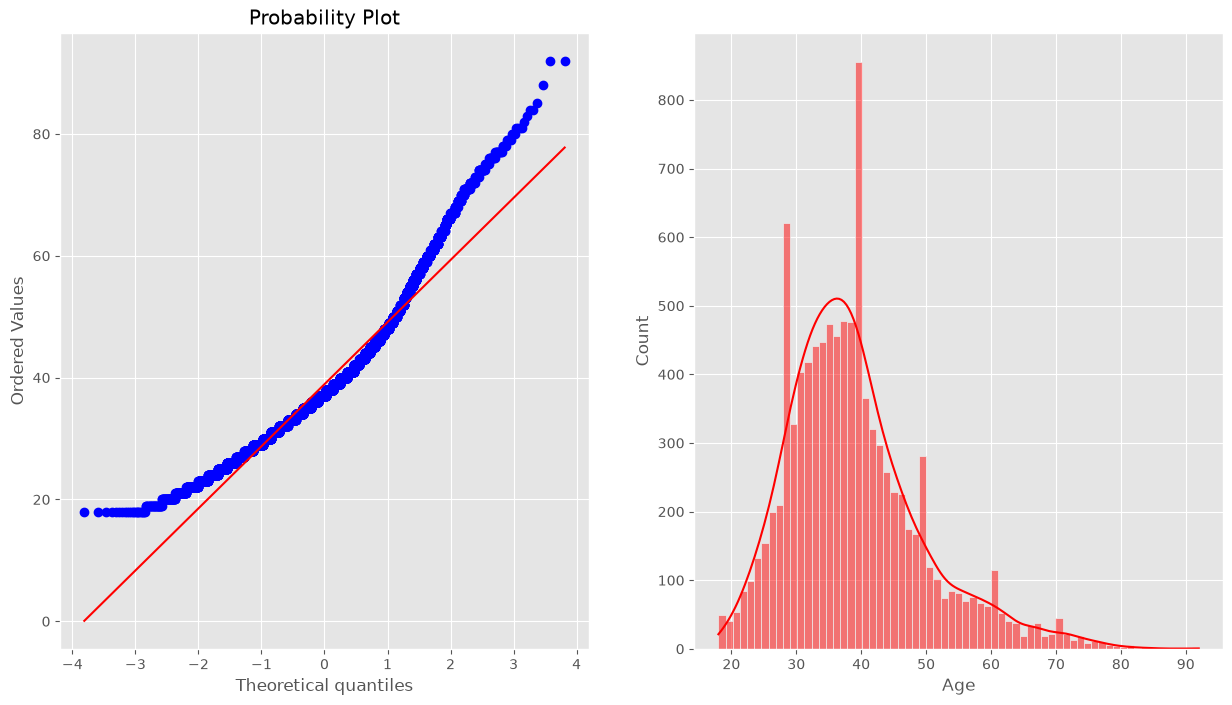

feature Age
 stat: 0.9441
p_value0.00000000
Shapiro Wilk test
the dist of Age is not signfically normal 
Skewness: 1.0112
  The distribution is right-skewed (positively skewed).
Kurtosis: 1.3940
  The distribution is leptokurtic (heavier tails, more outliers than normal).




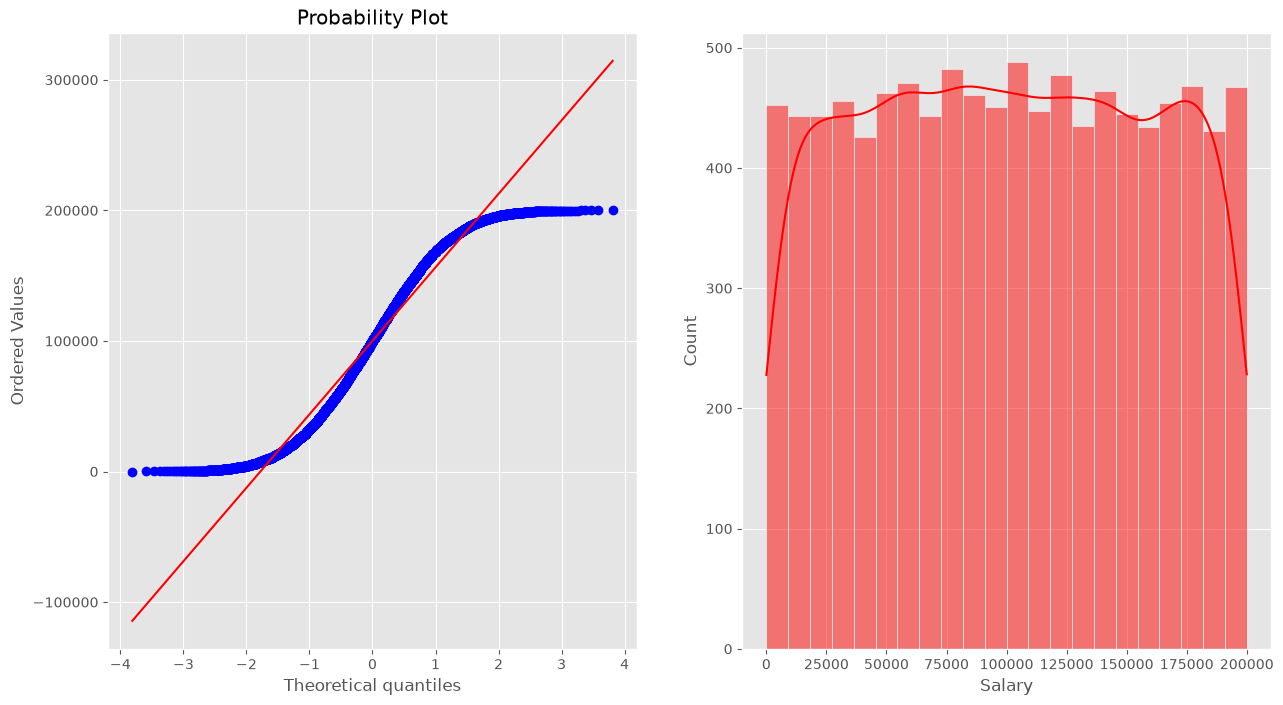

feature Salary
 stat: 0.9566
p_value0.00000000
Shapiro Wilk test
the dist of Salary is not signfically normal 
Skewness: 0.0021
  The distribution is approximately symmetric.
Kurtosis: -1.1815
  The distribution is platykurtic (lighter tails, fewer outliers than normal).




In [19]:
from scipy import stats
def checking_normality(data,features):
    plt.figure(figsize=(15,8))
    plt.subplot(1,2,1)
    stats.probplot(data[features],dist="norm",plot=plt)

    plt.subplot(1,2,2)
    sns.histplot(data[features],kde=True, color="red")
    plt.show()

    print(f"feature {features}")
    stat,p_value=stats.shapiro(data[features])
    print(f" stat: {stat:.4f}")
    print(f"p_value{p_value:.8f}")

    print("Shapiro Wilk test")
    if p_value<0.05:
        print(f"the dist of {features} is not signfically normal ")
    else:
        print(f"the dist of {features} is signfically normal ")

    skewness=stats.skew(data[features])
    kurtosis=stats.kurtosis(data[features])

    print(f"Skewness: {skewness:.4f}")
    if abs(skewness) < 0.5:
        print("  The distribution is approximately symmetric.")
    elif skewness > 0.5:
        print("  The distribution is right-skewed (positively skewed).")
    else:  # skewness < -0.5
        print("  The distribution is left-skewed (negatively skewed).")

    print(f"Kurtosis: {kurtosis:.4f}")
    if abs(kurtosis) < 0.5:
        print("  The distribution has a similar tail weight as the normal distribution.")
    elif kurtosis > 0.5:
        print("  The distribution is leptokurtic (heavier tails, more outliers than normal).")
    else:  # kurtosis < -0.5
        print("  The distribution is platykurtic (lighter tails, fewer outliers than normal).")
    print("\n")

columns_dist = ["Age", "Salary"]
for feat in columns_dist:
    checking_normality(df, feat)